In [5]:
warnings.filterwarnings('ignore')
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [6]:
file_path = "flights_RUH.parquet"

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "mohammedalsubaie/king-khalid-international-airport-flights-dataset",
    file_path,
)

In [7]:
df.head()

,flight_number,aircraft.model,aircraft.reg,aircraft.modeS,airline.name,airline.iata,airline.icao,status,flight_type,codeshareStatus,...,origin_airport_icao,origin_airport_iata,movement.terminal,movement.quality,destination_airport_icao,destination_airport_iata,destination_airport_name,movement.airport.timeZone,movement.scheduledTime.utc,movement.scheduledTime.local
0,PF 769,Airbus A320,None,None,Air Sial,PF,None,Unknown,departure,Unknown,...,OERK,RUH,2,[Basic],OPIS,ISB,Islamabad,Asia/Karachi,2025-03-14 21:01Z,2025-03-15 00:01+03:00
1,XY 333,Airbus A320 NEO,HZ-NS35,710DB9,flynas,XY,KNE,Unknown,departure,IsOperator,...,OERK,RUH,1,[Basic],VILK,LKO,Lucknow,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
2,QP 568,Boeing 737,None,None,Starlight Airline,QP,SLT,Unknown,departure,Unknown,...,OERK,RUH,3,[Basic],VABB,BOM,Mumbai,Asia/Kolkata,2025-03-14 21:05Z,2025-03-15 00:05+03:00
3,F3 161,Airbus A320,None,None,flyadeal,F3,FAD,Unknown,departure,Unknown,...,OERK,RUH,5,[Basic],OEJN,JED,Jeddah,Asia/Riyadh,2025-03-14 21:10Z,2025-03-15 00:10+03:00
4,KL 423,Airbus A330-300,None,None,KLM,KL,KLM,Unknown,departure,Unknown,...,OERK,RUH,1,[Basic],OEDF,DMM,Ad Dammam,Asia/Riyadh,2025-03-14 21:15Z,2025-03-15 00:15+03:00


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153308 entries, 0 to 153307
Data columns (total 23 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   flight_number                 153308 non-null  object
 1   aircraft.model                153122 non-null  object
 2   aircraft.reg                  36234 non-null   object
 3   aircraft.modeS                45331 non-null   object
 4   airline.name                  153308 non-null  object
 5   airline.iata                  153294 non-null  object
 6   airline.icao                  152745 non-null  object
 7   status                        153308 non-null  object
 8   flight_type                   153308 non-null  object
 9   codeshareStatus               153308 non-null  object
 10  isCargo                       153308 non-null  bool  
 11  callSign                      45137 non-null   object
 12  origin_airport_name           153308 non-null  object
 13 

In [9]:
columns_to_drop = ['aircraft.reg' , 'aircraft.modeS' , 'callSign' , 'movement.quality' , 'airline.icao' , 'origin_airport_icao' , 'destination_airport_icao']

df_cleaned = df.drop(columns= columns_to_drop)

In [10]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153308 entries, 0 to 153307
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   flight_number                 153308 non-null  object
 1   aircraft.model                153122 non-null  object
 2   airline.name                  153308 non-null  object
 3   airline.iata                  153294 non-null  object
 4   status                        153308 non-null  object
 5   flight_type                   153308 non-null  object
 6   codeshareStatus               153308 non-null  object
 7   isCargo                       153308 non-null  bool  
 8   origin_airport_name           153308 non-null  object
 9   origin_airport_iata           153308 non-null  object
 10  movement.terminal             152458 non-null  object
 11  destination_airport_iata      149202 non-null  object
 12  destination_airport_name      153308 non-null  object
 13 

In [11]:
df_cleaned['movement.scheduledTime.utc' ] = pd.to_datetime(df_cleaned['movement.scheduledTime.utc' ])
df_cleaned["movement.scheduledTime.local"] = pd.to_datetime(df_cleaned['movement.scheduledTime.local'])

In [12]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 153308 entries, 0 to 153307
Data columns (total 16 columns):
 #   Column                        Non-Null Count   Dtype                    
---  ------                        --------------   -----                    
 0   flight_number                 153308 non-null  object                   
 1   aircraft.model                153122 non-null  object                   
 2   airline.name                  153308 non-null  object                   
 3   airline.iata                  153294 non-null  object                   
 4   status                        153308 non-null  object                   
 5   flight_type                   153308 non-null  object                   
 6   codeshareStatus               153308 non-null  object                   
 7   isCargo                       153308 non-null  bool                     
 8   origin_airport_name           153308 non-null  object                   
 9   origin_airport_iata       

In [13]:
df_cleaned.isnull().sum()

flight_number                      0
aircraft.model                   186
airline.name                       0
airline.iata                      14
status                             0
flight_type                        0
codeshareStatus                    0
isCargo                            0
origin_airport_name                0
origin_airport_iata                0
movement.terminal                850
destination_airport_iata        4106
destination_airport_name           0
movement.airport.timeZone       4106
movement.scheduledTime.utc         0
movement.scheduledTime.local       0
dtype: int64

In [14]:
df_cleaned = df_cleaned.fillna('Unknown')

df_cleaned.isnull().sum()

flight_number                   0
aircraft.model                  0
airline.name                    0
airline.iata                    0
status                          0
flight_type                     0
codeshareStatus                 0
isCargo                         0
origin_airport_name             0
origin_airport_iata             0
movement.terminal               0
destination_airport_iata        0
destination_airport_name        0
movement.airport.timeZone       0
movement.scheduledTime.utc      0
movement.scheduledTime.local    0
dtype: int64

In [15]:
df_cleaned['flight_hour'] = df_cleaned['movement.scheduledTime.local'].dt.hour
df_cleaned['flight_day'] = df_cleaned['movement.scheduledTime.local'].dt.day_name()
df_cleaned[['movement.scheduledTime.local' , 'flight_hour' , 'flight_day']].head()

,movement.scheduledTime.local,flight_hour,flight_day
0,2025-03-15 00:01:00+03:00,0,Saturday
1,2025-03-15 00:05:00+03:00,0,Saturday
2,2025-03-15 00:05:00+03:00,0,Saturday
3,2025-03-15 00:10:00+03:00,0,Saturday
4,2025-03-15 00:15:00+03:00,0,Saturday


In [16]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


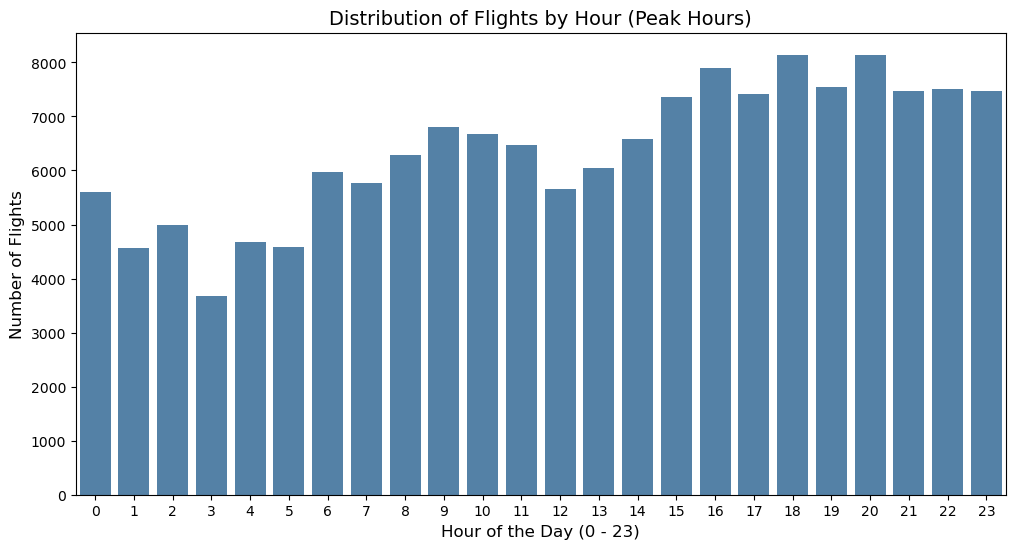

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(data=df_cleaned, x='flight_hour', color='steelblue')

plt.title('Distribution of Flights by Hour (Peak Hours)', fontsize=14)
plt.xlabel('Hour of the Day (0 - 23)', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)

plt.show()

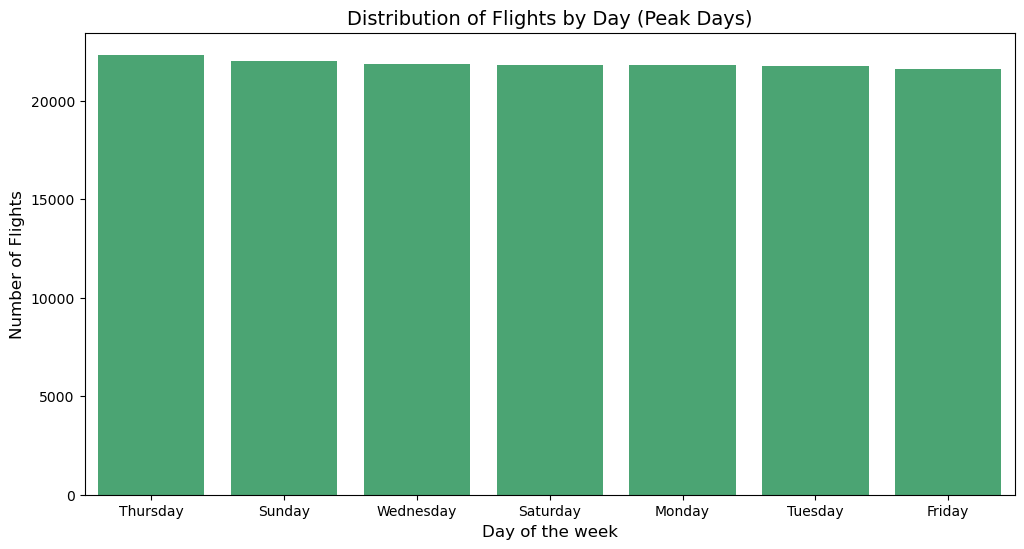

In [18]:
plt.figure(figsize=(12,6))

sns.countplot(data= df_cleaned, x= 'flight_day' ,color= 'mediumseagreen',
              order=df_cleaned['flight_day'].value_counts().index)

plt.title('Distribution of Flights by Day (Peak Days)', fontsize=14)
plt.xlabel('Day of the week', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)

plt.show()

In [19]:
df_cleaned.head()

,flight_number,aircraft.model,airline.name,airline.iata,status,flight_type,codeshareStatus,isCargo,origin_airport_name,origin_airport_iata,movement.terminal,destination_airport_iata,destination_airport_name,movement.airport.timeZone,movement.scheduledTime.utc,movement.scheduledTime.local,flight_hour,flight_day
0,PF 769,Airbus A320,Air Sial,PF,Unknown,departure,Unknown,False,Riyadh,RUH,2,ISB,Islamabad,Asia/Karachi,2025-03-14 21:01:00+00:00,2025-03-15 00:01:00+03:00,0,Saturday
1,XY 333,Airbus A320 NEO,flynas,XY,Unknown,departure,IsOperator,False,Riyadh,RUH,1,LKO,Lucknow,Asia/Kolkata,2025-03-14 21:05:00+00:00,2025-03-15 00:05:00+03:00,0,Saturday
2,QP 568,Boeing 737,Starlight Airline,QP,Unknown,departure,Unknown,False,Riyadh,RUH,3,BOM,Mumbai,Asia/Kolkata,2025-03-14 21:05:00+00:00,2025-03-15 00:05:00+03:00,0,Saturday
3,F3 161,Airbus A320,flyadeal,F3,Unknown,departure,Unknown,False,Riyadh,RUH,5,JED,Jeddah,Asia/Riyadh,2025-03-14 21:10:00+00:00,2025-03-15 00:10:00+03:00,0,Saturday
4,KL 423,Airbus A330-300,KLM,KL,Unknown,departure,Unknown,False,Riyadh,RUH,1,DMM,Ad Dammam,Asia/Riyadh,2025-03-14 21:15:00+00:00,2025-03-15 00:15:00+03:00,0,Saturday


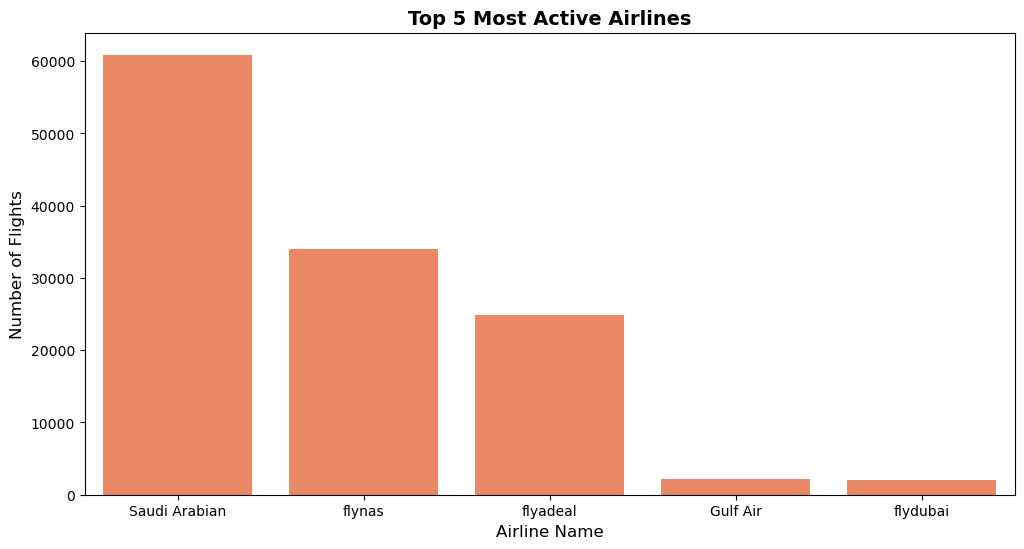

In [20]:
plt.figure(figsize=(12,6))
top_5_airlines = df_cleaned['airline.name'].value_counts().head().index

sns.countplot(data=df_cleaned, x='airline.name', order= top_5_airlines, color='coral')

plt.title('Top 5 Most Active Airlines', fontsize=14, fontweight='bold')
plt.xlabel('Airline Name', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)

plt.show()

In [21]:
df_cleaned.head()

,flight_number,aircraft.model,airline.name,airline.iata,status,flight_type,codeshareStatus,isCargo,origin_airport_name,origin_airport_iata,movement.terminal,destination_airport_iata,destination_airport_name,movement.airport.timeZone,movement.scheduledTime.utc,movement.scheduledTime.local,flight_hour,flight_day
0,PF 769,Airbus A320,Air Sial,PF,Unknown,departure,Unknown,False,Riyadh,RUH,2,ISB,Islamabad,Asia/Karachi,2025-03-14 21:01:00+00:00,2025-03-15 00:01:00+03:00,0,Saturday
1,XY 333,Airbus A320 NEO,flynas,XY,Unknown,departure,IsOperator,False,Riyadh,RUH,1,LKO,Lucknow,Asia/Kolkata,2025-03-14 21:05:00+00:00,2025-03-15 00:05:00+03:00,0,Saturday
2,QP 568,Boeing 737,Starlight Airline,QP,Unknown,departure,Unknown,False,Riyadh,RUH,3,BOM,Mumbai,Asia/Kolkata,2025-03-14 21:05:00+00:00,2025-03-15 00:05:00+03:00,0,Saturday
3,F3 161,Airbus A320,flyadeal,F3,Unknown,departure,Unknown,False,Riyadh,RUH,5,JED,Jeddah,Asia/Riyadh,2025-03-14 21:10:00+00:00,2025-03-15 00:10:00+03:00,0,Saturday
4,KL 423,Airbus A330-300,KLM,KL,Unknown,departure,Unknown,False,Riyadh,RUH,1,DMM,Ad Dammam,Asia/Riyadh,2025-03-14 21:15:00+00:00,2025-03-15 00:15:00+03:00,0,Saturday


In [22]:
df_cleaned['flight_date'] = df_cleaned['movement.scheduledTime.local'].dt.date

average_flights = df_cleaned.groupby('flight_date').size().mean()

print(f'Average number of flights per day: {average_flights:.0f}')

Average number of flights per day: 730


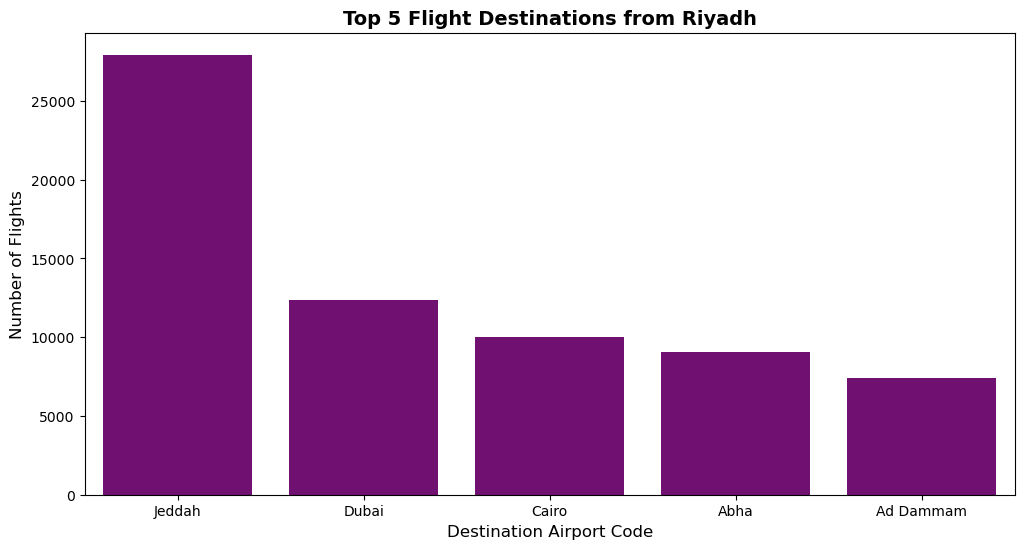

In [23]:
plt.figure(figsize=(12,6))

top_5_distination = df_cleaned['destination_airport_name'].value_counts().head().index

sns.countplot(data=df_cleaned , x='destination_airport_name' , order=top_5_distination ,color='purple')

plt.title('Top 5 Flight Destinations from Riyadh', fontsize=14, fontweight='bold')
plt.xlabel('Destination Airport Code', fontsize=12)
plt.ylabel('Number of Flights', fontsize=12)

plt.show()

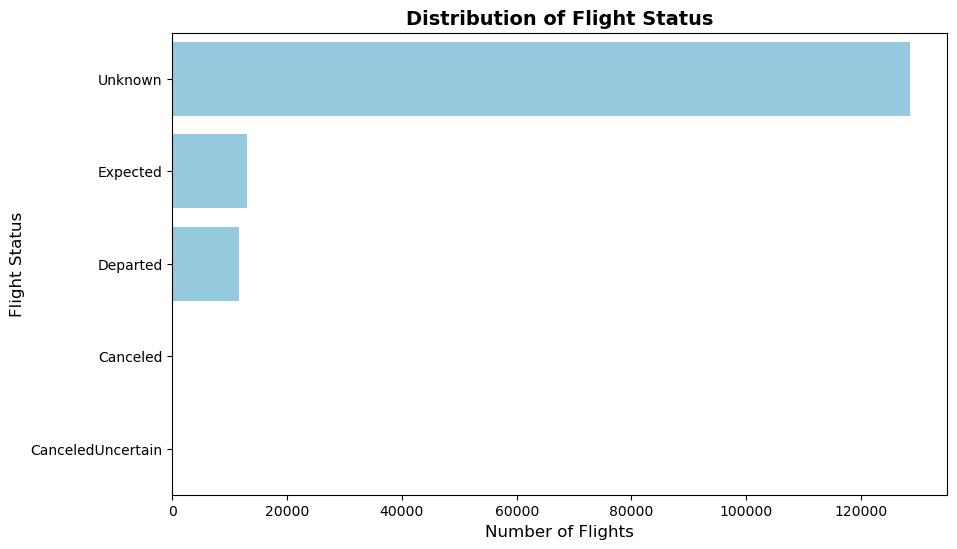

In [24]:
plt.figure(figsize=(10, 6))

status_counts = df_cleaned['status'].value_counts().index

sns.countplot(data=df_cleaned, y='status', order=status_counts, color='skyblue')

plt.title('Distribution of Flight Status', fontsize=14, fontweight='bold')
plt.xlabel('Number of Flights', fontsize=12)
plt.ylabel('Flight Status', fontsize=12)

plt.show()

In [25]:
df_cleaned.to_csv('cleaned_riyadh_flights.csv', index=False)
